## Libraries Used

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, sum, avg, count, min, max, round,
    hour, dayofweek, when, create_map, lit, unix_timestamp
)
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("BIG DATA ANALYSIS USING PYSPARK") \
    .getOrCreate()

print("PySpark is working successfully!")

PySpark is working successfully!


### Dataset Source

The dataset used in this project is the NYC Yellow Taxi Trip Data for January 2024.

Dataset source: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

In [ ]:
df = spark.read.parquet("yellow_tripdata_2024-01.parquet")

In [ ]:
df.show(5)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       2| 2024-01-01 00:57:55|  2024-01-01 01:17:43|              1|         1.72|         1|                 N|         186|          79|           2|       17.7|  1.0|    0.5|       0.

In [ ]:
df.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)



In [ ]:
total_trips = df.count()
print("Total number of taxi trips:", total_trips)

Total number of taxi trips: 2964624


In [ ]:
from pyspark.sql.functions import col, sum

df.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
]).show()

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       0|                   0|                    0|         140162|            0|    140162|            140162|           0|           0|           0|          0|    0|      0|         

In [ ]:
df.select(
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount"
).describe().show()

+-------+------------------+------------------+------------------+------------------+------------------+
|summary|   passenger_count|     trip_distance|       fare_amount|        tip_amount|      total_amount|
+-------+------------------+------------------+------------------+------------------+------------------+
|  count|           2824462|           2964624|           2964624|           2964624|           2964624|
|   mean|1.3392808966805005|3.6521691789580624|18.175061916792536| 3.335870015894562| 26.80150477092493|
| stddev|0.8502816924800862|225.46257238220082|18.949547705905324|3.8965505998067607|23.385577429672043|
|    min|                 0|               0.0|            -899.0|             -80.0|            -900.0|
|    max|                 9|          312722.3|            5000.0|             428.0|            5000.0|
+-------+------------------+------------------+------------------+------------------+------------------+



In [ ]:
from pyspark.sql.functions import col

suspicious_trips = df.filter(
    (col("trip_distance") <= 0) |
    (col("trip_distance") > 100) |
    (col("fare_amount") <= 0) |
    (col("total_amount") <= 0) |
    (col("passenger_count") <= 0)
)

print("Number of suspicious trips:", suspicious_trips.count())

Number of suspicious trips: 125626


In [ ]:
clean_df = df.filter(
    (col("trip_distance") > 0) &
    (col("trip_distance") <= 100) &
    (col("fare_amount") > 0) &
    (col("total_amount") > 0) &
    (col("passenger_count") > 0)
)

print("Original records:", df.count())
print("Cleaned records:", clean_df.count())

Original records: 2964624
Cleaned records: 2723770


In [ ]:
clean_df.select(
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount"
).describe().show()

+-------+------------------+------------------+------------------+------------------+-----------------+
|summary|   passenger_count|     trip_distance|       fare_amount|        tip_amount|     total_amount|
+-------+------------------+------------------+------------------+------------------+-----------------+
|  count|           2723770|           2723770|           2723770|           2723770|          2723770|
|   mean|1.3547285563759055|3.2899196114207556|18.437266865413278|3.4712516952611194|27.40618867232318|
| stddev|0.8447986936993602| 4.416095449020224|17.331297269873453|3.8493192349474277|21.88198202244225|
|    min|                 1|              0.01|              0.01|               0.0|             1.01|
|    max|                 9|              99.0|            2221.3|             422.7|           2225.3|
+-------+------------------+------------------+------------------+------------------+-----------------+



In [ ]:
from pyspark.sql.functions import avg

clean_df.select(
    avg("trip_distance").alias("Average_Trip_Distance"),
    avg("fare_amount").alias("Average_Fare"),
    avg("total_amount").alias("Average_Total_Amount")
).show()

+---------------------+------------------+--------------------+
|Average_Trip_Distance|      Average_Fare|Average_Total_Amount|
+---------------------+------------------+--------------------+
|   3.2899196114207556|18.437266865413278|   27.40618867232318|
+---------------------+------------------+--------------------+



In [ ]:
from pyspark.sql.functions import count

clean_df.groupBy("passenger_count") \
    .agg(count("*").alias("Number_of_Trips")) \
    .orderBy("passenger_count") \
    .show()

+---------------+---------------+
|passenger_count|Number_of_Trips|
+---------------+---------------+
|              1|        2134598|
|              2|         395090|
|              3|          88966|
|              4|          49590|
|              5|          33305|
|              6|          22178|
|              7|              5|
|              8|             37|
|              9|              1|
+---------------+---------------+



In [ ]:
clean_df.groupBy("payment_type") \
    .agg(count("*").alias("Number_of_Trips")) \
    .orderBy("Number_of_Trips", ascending=False) \
    .show()

+------------+---------------+
|payment_type|Number_of_Trips|
+------------+---------------+
|           1|        2273561|
|           2|         417797|
|           4|          22606|
|           3|           9806|
+------------+---------------+



In [ ]:
payment_type_mapping = {
    1: "Credit card",
    2: "Cash",
    3: "No charge",
    4: "Dispute"
}

from pyspark.sql.functions import create_map, lit

mapping_expr = create_map(
    [lit(x) for pair in payment_type_mapping.items() for x in pair]
)

clean_df = clean_df.withColumn(
    "payment_method",
    mapping_expr[col("payment_type")]
)

clean_df.groupBy("payment_method") \
    .count() \
    .orderBy("count", ascending=False) \
    .show()

+--------------+-------+
|payment_method|  count|
+--------------+-------+
|   Credit card|2273561|
|          Cash| 417797|
|       Dispute|  22606|
|     No charge|   9806|
+--------------+-------+



In [ ]:
from pyspark.sql.functions import round

payment_summary = clean_df.groupBy("payment_method") \
    .count() \
    .withColumn(
        "Percentage",
        round(col("count") / clean_df.count() * 100, 2)
    ) \
    .orderBy(col("count").desc())

payment_summary.show()

+--------------+-------+----------+
|payment_method|  count|Percentage|
+--------------+-------+----------+
|   Credit card|2273561|     83.47|
|          Cash| 417797|     15.34|
|       Dispute|  22606|      0.83|
|     No charge|   9806|      0.36|
+--------------+-------+----------+



In [ ]:
from pyspark.sql.functions import min, max, avg, round

clean_df.select(
    round(avg("trip_distance"), 2).alias("Average_Distance"),
    round(min("trip_distance"), 2).alias("Minimum_Distance"),
    round(max("trip_distance"), 2).alias("Maximum_Distance")
).show()

+----------------+----------------+----------------+
|Average_Distance|Minimum_Distance|Maximum_Distance|
+----------------+----------------+----------------+
|            3.29|            0.01|            99.0|
+----------------+----------------+----------------+



In [ ]:
clean_df.select(
    round(avg("fare_amount"), 2).alias("Average_Fare"),
    round(min("fare_amount"), 2).alias("Minimum_Fare"),
    round(max("fare_amount"), 2).alias("Maximum_Fare")
).show()

+------------+------------+------------+
|Average_Fare|Minimum_Fare|Maximum_Fare|
+------------+------------+------------+
|       18.44|        0.01|      2221.3|
+------------+------------+------------+



In [ ]:
high_fare_trips = clean_df.filter(
    col("fare_amount") > 100
)

print("Trips with fare above $100:", high_fare_trips.count())

Trips with fare above $100: 6963


In [ ]:
from pyspark.sql.functions import unix_timestamp

clean_df = clean_df.withColumn(
    "trip_duration_minutes",
    (
        unix_timestamp("tpep_dropoff_datetime") -
        unix_timestamp("tpep_pickup_datetime")
    ) / 60
)

clean_df.select(
    round(avg("trip_duration_minutes"), 2).alias("Average_Duration_Minutes"),
    round(min("trip_duration_minutes"), 2).alias("Minimum_Duration_Minutes"),
    round(max("trip_duration_minutes"), 2).alias("Maximum_Duration_Minutes")
).show()

+------------------------+------------------------+------------------------+
|Average_Duration_Minutes|Minimum_Duration_Minutes|Maximum_Duration_Minutes|
+------------------------+------------------------+------------------------+
|                   15.76|                  -13.57|                  9455.4|
+------------------------+------------------------+------------------------+



In [ ]:
duration_check = clean_df.filter(
    (col("trip_duration_minutes") <= 0) |
    (col("trip_duration_minutes") > 180)
)

print("Suspicious duration records:", duration_check.count())

Suspicious duration records: 1991


In [ ]:
analysis_df = clean_df.filter(
    (col("trip_duration_minutes") > 0) &
    (col("trip_duration_minutes") <= 180)
)

print("Records after duration cleaning:", analysis_df.count())

Records after duration cleaning: 2721779


In [ ]:
analysis_df.select(
    round(avg("trip_duration_minutes"), 2).alias("Average_Duration_Minutes"),
    round(min("trip_duration_minutes"), 2).alias("Minimum_Duration_Minutes"),
    round(max("trip_duration_minutes"), 2).alias("Maximum_Duration_Minutes")
).show()

+------------------------+------------------------+------------------------+
|Average_Duration_Minutes|Minimum_Duration_Minutes|Maximum_Duration_Minutes|
+------------------------+------------------------+------------------------+
|                   14.92|                    0.02|                  179.07|
+------------------------+------------------------+------------------------+



In [ ]:
from pyspark.sql.functions import hour, count

hourly_trips = analysis_df.groupBy(
    hour("tpep_pickup_datetime").alias("Pickup_Hour")
).agg(
    count("*").alias("Number_of_Trips")
).orderBy("Pickup_Hour")

hourly_trips.show(24)

+-----------+---------------+
|Pickup_Hour|Number_of_Trips|
+-----------+---------------+
|          0|          69110|
|          1|          45324|
|          2|          31895|
|          3|          20524|
|          4|          12760|
|          5|          15621|
|          6|          35561|
|          7|          74266|
|          8|         105064|
|          9|         119313|
|         10|         129944|
|         11|         141166|
|         12|         153516|
|         13|         158941|
|         14|         171120|
|         15|         176821|
|         16|         178267|
|         17|         191112|
|         18|         195792|
|         19|         170466|
|         20|         149168|
|         21|         148299|
|         22|         130453|
|         23|          97276|
+-----------+---------------+



In [ ]:
hourly_trips.orderBy(
    col("Number_of_Trips").desc()
).show(1)

+-----------+---------------+
|Pickup_Hour|Number_of_Trips|
+-----------+---------------+
|         18|         195792|
+-----------+---------------+
only showing top 1 row


In [ ]:
from pyspark.sql.functions import dayofweek

daily_trips = analysis_df.groupBy(
    dayofweek("tpep_pickup_datetime").alias("Day_Number")
).agg(
    count("*").alias("Number_of_Trips")
).orderBy("Day_Number")

daily_trips.show()

+----------+---------------+
|Day_Number|Number_of_Trips|
+----------+---------------+
|         1|         306153|
|         2|         372115|
|         3|         425619|
|         4|         458474|
|         5|         397203|
|         6|         378299|
|         7|         383916|
+----------+---------------+



In [ ]:
daily_trips.orderBy(
    col("Number_of_Trips").desc()
).show(1)

+----------+---------------+
|Day_Number|Number_of_Trips|
+----------+---------------+
|         4|         458474|
+----------+---------------+
only showing top 1 row


In [ ]:
daily_fare = analysis_df.groupBy(
    dayofweek("tpep_pickup_datetime").alias("Day_Number")
).agg(
    round(avg("fare_amount"), 2).alias("Average_Fare")
).orderBy("Day_Number")

daily_fare.show()

+----------+------------+
|Day_Number|Average_Fare|
+----------+------------+
|         1|        18.7|
|         2|       19.62|
|         3|       18.57|
|         4|       18.38|
|         5|       18.54|
|         6|       18.12|
|         7|       17.16|
+----------+------------+



In [ ]:
tip_by_payment = analysis_df.groupBy(
    "payment_method"
).agg(
    round(avg("tip_amount"), 2).alias("Average_Tip")
).orderBy(
    col("Average_Tip").desc()
)

tip_by_payment.show()

+--------------+-----------+
|payment_method|Average_Tip|
+--------------+-----------+
|   Credit card|       4.16|
|     No charge|       0.01|
|          Cash|        0.0|
|       Dispute|        0.0|
+--------------+-----------+



In [ ]:
revenue_by_payment = analysis_df.groupBy(
    "payment_method"
).agg(
    round(sum("total_amount"), 2).alias("Total_Revenue")
).orderBy(
    col("Total_Revenue").desc()
)

revenue_by_payment.show()

+--------------+-------------+
|payment_method|Total_Revenue|
+--------------+-------------+
|   Credit card|6.383902563E7|
|          Cash|   9952217.55|
|       Dispute|    567567.88|
|     No charge|    220068.39|
+--------------+-------------+



In [ ]:
tip_by_hour = analysis_df.groupBy(
    hour("tpep_pickup_datetime").alias("Pickup_Hour")
).agg(
    round(avg("tip_amount"), 2).alias("Average_Tip")
).orderBy("Pickup_Hour")

tip_by_hour.show(24)

+-----------+-----------+
|Pickup_Hour|Average_Tip|
+-----------+-----------+
|          0|       3.62|
|          1|       3.27|
|          2|       3.07|
|          3|       3.13|
|          4|       3.58|
|          5|       4.09|
|          6|       3.35|
|          7|       3.21|
|          8|       3.18|
|          9|       3.24|
|         10|       3.22|
|         11|       3.18|
|         12|       3.21|
|         13|       3.32|
|         14|       3.48|
|         15|       3.43|
|         16|       3.77|
|         17|       3.62|
|         18|        3.5|
|         19|        3.6|
|         20|       3.61|
|         21|       3.68|
|         22|       3.77|
|         23|       3.82|
+-----------+-----------+



In [ ]:
from pyspark.sql.functions import when

distance_fare = analysis_df.withColumn(
    "Distance_Category",
    when(col("trip_distance") <= 2, "0-2 miles")
    .when(col("trip_distance") <= 5, "2-5 miles")
    .when(col("trip_distance") <= 10, "5-10 miles")
    .when(col("trip_distance") <= 20, "10-20 miles")
    .otherwise("20+ miles")
)

distance_fare.groupBy("Distance_Category") \
    .agg(
        count("*").alias("Number_of_Trips"),
        round(avg("fare_amount"), 2).alias("Average_Fare")
    ) \
    .orderBy("Distance_Category") \
    .show()

+-----------------+---------------+------------+
|Distance_Category|Number_of_Trips|Average_Fare|
+-----------------+---------------+------------+
|        0-2 miles|        1594885|        9.91|
|      10-20 miles|         188896|        61.1|
|        2-5 miles|         697955|       18.67|
|        20+ miles|          28091|       90.31|
|       5-10 miles|         211952|       34.19|
+-----------------+---------------+------------+



In [ ]:
top_pickup_locations = analysis_df.groupBy(
    "PULocationID"
).agg(
    count("*").alias("Number_of_Trips")
).orderBy(
    col("Number_of_Trips").desc()
)

top_pickup_locations.show(10)

+------------+---------------+
|PULocationID|Number_of_Trips|
+------------+---------------+
|         132|         136763|
|         237|         135399|
|         161|         134887|
|         236|         128026|
|         162|         101195|
|         186|          99396|
|         230|          98883|
|         142|          97539|
|         138|          86512|
|         239|          81298|
+------------+---------------+
only showing top 10 rows


In [ ]:
top_dropoff_locations = analysis_df.groupBy(
    "DOLocationID"
).agg(
    count("*").alias("Number_of_Trips")
).orderBy(
    col("Number_of_Trips").desc()
)

top_dropoff_locations.show(10)

+------------+---------------+
|DOLocationID|Number_of_Trips|
+------------+---------------+
|         236|         133524|
|         237|         122743|
|         161|         104726|
|         230|          83982|
|         142|          83741|
|         239|          82965|
|         170|          80723|
|         162|          79676|
|         141|          78084|
|          68|          68654|
+------------+---------------+
only showing top 10 rows


In [ ]:
passenger_fare = analysis_df.groupBy(
    "passenger_count"
).agg(
    count("*").alias("Number_of_Trips"),
    round(avg("total_amount"), 2).alias("Average_Total_Amount")
).orderBy("passenger_count")

passenger_fare.show()

+---------------+---------------+--------------------+
|passenger_count|Number_of_Trips|Average_Total_Amount|
+---------------+---------------+--------------------+
|              1|        2133192|               26.74|
|              2|         394849|               30.15|
|              3|          88914|               29.71|
|              4|          49540|               31.31|
|              5|          33164|               26.38|
|              6|          22077|                25.8|
|              7|              5|               66.28|
|              8|             37|              102.97|
|              9|              1|               18.45|
+---------------+---------------+--------------------+



In [ ]:
overall_revenue = analysis_df.select(
    round(sum("total_amount"), 2).alias("Total_Revenue")
)

overall_revenue.show()

+-------------+
|Total_Revenue|
+-------------+
|7.457887945E7|
+-------------+



In [ ]:
hourly_amount = analysis_df.groupBy(
    hour("tpep_pickup_datetime").alias("Pickup_Hour")
).agg(
    round(avg("total_amount"), 2).alias("Average_Total_Amount")
).orderBy("Pickup_Hour")

hourly_amount.show(24)

+-----------+--------------------+
|Pickup_Hour|Average_Total_Amount|
+-----------+--------------------+
|          0|               28.91|
|          1|               25.88|
|          2|                24.6|
|          3|               26.37|
|          4|               32.51|
|          5|                37.9|
|          6|               30.27|
|          7|                26.4|
|          8|               25.39|
|          9|               25.85|
|         10|               26.02|
|         11|               25.47|
|         12|               25.73|
|         13|                26.5|
|         14|               27.66|
|         15|                27.4|
|         16|               29.79|
|         17|               28.22|
|         18|               26.94|
|         19|               27.81|
|         20|               27.42|
|         21|               27.65|
|         22|               28.65|
|         23|               30.01|
+-----------+--------------------+



In [ ]:
top_expensive_trips = analysis_df.select(
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount"
).orderBy(
    col("total_amount").desc()
)

top_expensive_trips.show(10, truncate=False)

+--------------------+---------------------+-------------+-----------+----------+------------+
|tpep_pickup_datetime|tpep_dropoff_datetime|trip_distance|fare_amount|tip_amount|total_amount|
+--------------------+---------------------+-------------+-----------+----------+------------+
|2024-01-01 21:59:33 |2024-01-01 21:59:55  |0.21         |820.0      |0.0       |821.0       |
|2024-01-07 12:38:39 |2024-01-07 12:38:59  |0.11         |700.0      |0.0       |715.75      |
|2024-01-29 19:19:21 |2024-01-29 19:24:05  |2.46         |650.0      |0.0       |652.75      |
|2024-01-24 21:40:43 |2024-01-24 23:34:07  |94.47        |637.9      |0.0       |648.59      |
|2024-01-28 14:41:20 |2024-01-28 16:37:25  |92.34        |607.8      |0.0       |637.87      |
|2024-01-02 08:51:02 |2024-01-02 10:57:09  |97.12        |620.4      |0.0       |630.09      |
|2024-01-27 15:42:54 |2024-01-27 17:28:22  |99.0         |591.7      |0.0       |623.71      |
|2024-01-17 00:54:07 |2024-01-17 02:33:20  |97.22 

In [ ]:
extreme_fares = analysis_df.filter(
    col("total_amount") > 500
)

print("Trips with total amount above $500:", extreme_fares.count())


Trips with total amount above $500: 26


In [ ]:
extreme_fares.select(
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount"
).orderBy(
    col("total_amount").desc()
).show(26, truncate=False)

+--------------------+---------------------+-------------+-----------+----------+------------+
|tpep_pickup_datetime|tpep_dropoff_datetime|trip_distance|fare_amount|tip_amount|total_amount|
+--------------------+---------------------+-------------+-----------+----------+------------+
|2024-01-01 21:59:33 |2024-01-01 21:59:55  |0.21         |820.0      |0.0       |821.0       |
|2024-01-07 12:38:39 |2024-01-07 12:38:59  |0.11         |700.0      |0.0       |715.75      |
|2024-01-29 19:19:21 |2024-01-29 19:24:05  |2.46         |650.0      |0.0       |652.75      |
|2024-01-24 21:40:43 |2024-01-24 23:34:07  |94.47        |637.9      |0.0       |648.59      |
|2024-01-28 14:41:20 |2024-01-28 16:37:25  |92.34        |607.8      |0.0       |637.87      |
|2024-01-02 08:51:02 |2024-01-02 10:57:09  |97.12        |620.4      |0.0       |630.09      |
|2024-01-27 15:42:54 |2024-01-27 17:28:22  |99.0         |591.7      |0.0       |623.71      |
|2024-01-17 00:54:07 |2024-01-17 02:33:20  |97.22 

In [ ]:
suspicious_short_trips = analysis_df.filter(
    (col("total_amount") > 500) &
    (col("trip_distance") < 5)
)

print(
    "Suspicious high-fare short trips:",
    suspicious_short_trips.count()
)

Suspicious high-fare short trips: 5


In [ ]:
suspicious_short_trips.select(
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount"
).orderBy(
    col("total_amount").desc()
).show(5, truncate=False)

+--------------------+---------------------+-------------+-----------+----------+------------+
|tpep_pickup_datetime|tpep_dropoff_datetime|trip_distance|fare_amount|tip_amount|total_amount|
+--------------------+---------------------+-------------+-----------+----------+------------+
|2024-01-01 21:59:33 |2024-01-01 21:59:55  |0.21         |820.0      |0.0       |821.0       |
|2024-01-07 12:38:39 |2024-01-07 12:38:59  |0.11         |700.0      |0.0       |715.75      |
|2024-01-29 19:19:21 |2024-01-29 19:24:05  |2.46         |650.0      |0.0       |652.75      |
|2024-01-18 11:30:18 |2024-01-18 11:30:26  |0.01         |500.0      |0.0       |501.0       |
|2024-01-29 21:39:18 |2024-01-29 21:39:56  |1.5          |500.0      |0.0       |501.0       |
+--------------------+---------------------+-------------+-----------+----------+------------+



In [ ]:
analysis_df = analysis_df.withColumn(
    "Fare_Outlier",
    when(
        (col("total_amount") > 500) &
        (col("trip_distance") < 5),
        "Suspicious"
    ).otherwise("Normal")
)

analysis_df.groupBy("Fare_Outlier") \
    .count() \
    .show()

+------------+-------+
|Fare_Outlier|  count|
+------------+-------+
|  Suspicious|      5|
|      Normal|2721774|
+------------+-------+



In [ ]:
from pyspark.sql.functions import sum, when

outlier_summary = analysis_df.select(
    count("*").alias("Total_Trips"),
    sum(
        when(col("Fare_Outlier") == "Suspicious", 1).otherwise(0)
    ).alias("Suspicious_Trips")
).withColumn(
    "Suspicious_Percentage",
    round(
        col("Suspicious_Trips") / col("Total_Trips") * 100,
        4
    )
)

outlier_summary.show()

+-----------+----------------+---------------------+
|Total_Trips|Suspicious_Trips|Suspicious_Percentage|
+-----------+----------------+---------------------+
|    2721779|               5|               2.0E-4|
+-----------+----------------+---------------------+



In [ ]:
analysis_df.select(
    *[
        sum(
            when(col(c).isNull(), 1).otherwise(0)
        ).alias(c)
        for c in analysis_df.columns
    ]
).show()

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+--------------+---------------------+------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|payment_method|trip_duration_minutes|Fare_Outlier|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+--------------+---------------------+------------+
|       0|                   0|      

In [ ]:
final_summary = analysis_df.select(
    count("*").alias("Total_Trips"),
    round(avg("trip_distance"), 2).alias("Average_Distance"),
    round(avg("fare_amount"), 2).alias("Average_Fare"),
    round(avg("total_amount"), 2).alias("Average_Total_Amount"),
    round(avg("trip_duration_minutes"), 2).alias("Average_Duration_Minutes"),
    round(sum("total_amount"), 2).alias("Total_Revenue")
)

final_summary.show()

+-----------+----------------+------------+--------------------+------------------------+-------------+
|Total_Trips|Average_Distance|Average_Fare|Average_Total_Amount|Average_Duration_Minutes|Total_Revenue|
+-----------+----------------+------------+--------------------+------------------------+-------------+
|    2721779|            3.29|       18.43|                27.4|                   14.92|7.457887945E7|
+-----------+----------------+------------+--------------------+------------------------+-------------+



In [ ]:
hourly_trips_pd = hourly_trips.toPandas()

hourly_trips_pd

,Pickup_Hour,Number_of_Trips
0,0,69110
1,1,45324
2,2,31895
3,3,20524
4,4,12760
5,5,15621
6,6,35561
7,7,74266
8,8,105064
9,9,119313


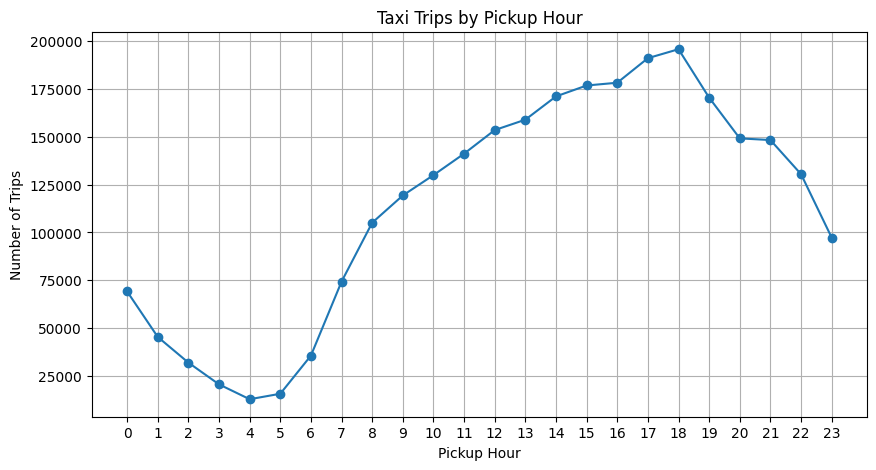

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_trips_pd["Pickup_Hour"],
    hourly_trips_pd["Number_of_Trips"],
    marker="o"
)

plt.title("Taxi Trips by Pickup Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Number of Trips")
plt.xticks(range(24))
plt.grid(True)

plt.show()

**Observation:** Taxi trips vary throughout the day, with the highest number of trips occurring during 18:00 (6 PM), while the lowest number of trips occurs during 4:00 AM.

In [ ]:
distance_fare.show()

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+--------------+---------------------+-----------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|payment_method|trip_duration_minutes|Distance_Category|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+--------------+---------------------+-----------------+
|       2| 2024-01-01 

In [ ]:
print(analysis_df.columns)

['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'payment_method', 'trip_duration_minutes', 'Fare_Outlier']


In [ ]:
from pyspark.sql.functions import when

analysis_df = analysis_df.withColumn(
    "Distance_Category",
    when(col("trip_distance") < 2, "0-2 miles")
    .when(col("trip_distance") < 5, "2-5 miles")
    .when(col("trip_distance") < 10, "5-10 miles")
    .when(col("trip_distance") < 20, "10-20 miles")
    .otherwise("20+ miles")
)

analysis_df.groupBy("Distance_Category") \
    .agg(
        count("*").alias("Number_of_Trips"),
        round(avg("fare_amount"), 2).alias("Average_Fare")
    ) \
    .show()

+-----------------+---------------+------------+
|Distance_Category|Number_of_Trips|Average_Fare|
+-----------------+---------------+------------+
|       5-10 miles|         213194|       34.06|
|        2-5 miles|         715289|       18.52|
|        20+ miles|          28411|        90.1|
|        0-2 miles|        1575198|        9.86|
|      10-20 miles|         189687|       60.97|
+-----------------+---------------+------------+



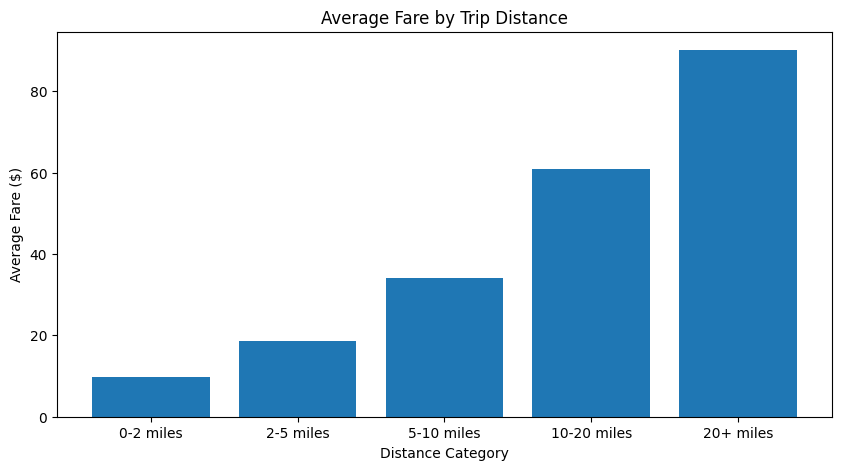

In [ ]:
import matplotlib.pyplot as plt

distance_data = {
    "0-2 miles": 9.86,
    "2-5 miles": 18.52,
    "5-10 miles": 34.06,
    "10-20 miles": 60.97,
    "20+ miles": 90.10
}

plt.figure(figsize=(10, 5))

plt.bar(
    distance_data.keys(),
    distance_data.values()
)

plt.title("Average Fare by Trip Distance")
plt.xlabel("Distance Category")
plt.ylabel("Average Fare ($)")

plt.show()

**Observation:** Average fare increases significantly as trip distance increases. Short trips of 0–2 miles have the lowest average fare of 9.86 USD, while trips of 20+ miles have the highest average fare of 90.10 USD.

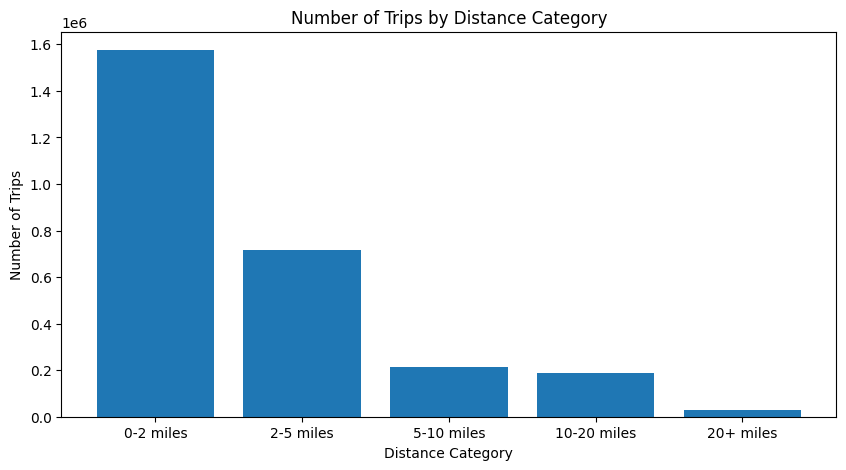

In [ ]:
import matplotlib.pyplot as plt

distance_trips = {
    "0-2 miles": 1575198,
    "2-5 miles": 715289,
    "5-10 miles": 213194,
    "10-20 miles": 189687,
    "20+ miles": 28411
}

plt.figure(figsize=(10, 5))

plt.bar(
    distance_trips.keys(),
    distance_trips.values()
)

plt.title("Number of Trips by Distance Category")
plt.xlabel("Distance Category")
plt.ylabel("Number of Trips")

plt.show()

**Observation:** Most trips fall within the 0–2 miles category, with 1,575,198 trips. The number of trips decreases as the distance category increases, with only 28,411 trips being 20+ miles.

## Final Insights

### Key Findings

- Taxi demand is highest at 6:00 PM and lowest at 4:00 AM, showing that trip demand varies significantly throughout the day.
- Average fare increases as trip distance increases, from 9.86 USD for 0–2 mile trips to 90.10 USD for 20+ mile trips.
- Most taxi trips are short-distance trips, with 1,575,198 trips in the 0–2 mile category.
- The number of trips decreases as the distance category increases, with only 28,411 trips being 20+ miles.

## Conclusion

This analysis shows that taxi demand varies throughout the day and across different trip distances. The highest number of trips occurs at 6:00 PM, while the lowest occurs at 4:00 AM. Most trips are short-distance trips of 0–2 miles, while longer trips are less frequent. The analysis also shows that average fare increases with trip distance, ranging from 9.86 USD for 0–2 mile trips to 90.10 USD for trips of 20+ miles. Overall, PySpark was useful for efficiently analyzing the large taxi dataset and identifying important patterns in trip demand and fare behavior.